# Exotic Derivatives Pricing & Heston Calibration Engine

End-to-end workflow:

1. Black-Scholes pricing and implied volatility
2. Synthetic implied-volatility surface
3. Heston pricing via the characteristic function
4. Heston calibration to the surface
5. Monte Carlo engines (GBM and Heston, full-truncation Euler)
6. Exotic products: arithmetic Asian call, up-and-out barrier call
7. 1-year equity Autocall under GBM vs Heston
8. Risk analytics

> The volatility surface is **synthetic**. Results illustrate the method, not market prices.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, least_squares

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

## 1. Black-Scholes pricing and implied volatility

In [2]:
def bs_price(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def implied_vol(price, S, K, T, r, option_type="call"):
    # Root-finding: find sigma such that BS price = observed price
    f = lambda s: bs_price(S, K, T, r, s, option_type) - price
    return brentq(f, 1e-4, 5.0)


# Sanity check: price -> implied vol -> same vol
p = bs_price(100, 100, 1, 0.03, 0.20)
print(f"BS call price: {p:.4f} | implied vol recovered: {implied_vol(p, 100, 100, 1, 0.03):.4%}")

BS call price: 9.4134 | implied vol recovered: 20.0000%


## 2. Synthetic implied-volatility surface

Strikes 80–120, maturities 1M–2Y. The surface has a **negative skew** (higher vol for low strikes, typical of equity markets) and a mild **term structure**.

In [3]:
S0, r = 100.0, 0.03
strikes = np.array([80, 90, 100, 110, 120], dtype=float)
maturities = np.array([1/12, 3/12, 6/12, 1.0, 2.0])
mat_labels = ["1M", "3M", "6M", "1Y", "2Y"]

def synthetic_iv(K, T):
    m = np.log(K / S0)                       # log-moneyness
    atm = 0.20 + 0.02 * (1 - np.exp(-T))     # term structure
    skew = -0.35 / np.sqrt(1 + 4 * T)        # skew flattens with maturity
    smile = 0.25 / (1 + 4 * T)
    return atm + skew * m + smile * m**2

iv_surface = pd.DataFrame(
    [[synthetic_iv(K, T) for K in strikes] for T in maturities],
    index=mat_labels, columns=strikes.astype(int))
market_prices = pd.DataFrame(
    [[bs_price(S0, K, T, r, synthetic_iv(K, T)) for K in strikes] for T in maturities],
    index=mat_labels, columns=strikes.astype(int))

print("Implied volatility surface (%):")
display((iv_surface * 100).round(2))

Implied volatility surface (%):


,80,90,100,110,120
1M,27.86,23.56,20.16,17.44,15.26
3M,26.59,23.19,20.44,18.20,16.35
6M,25.71,23.01,20.79,18.94,17.38
1Y,25.01,22.97,21.26,19.82,18.58
2Y,24.47,22.99,21.73,20.64,19.69


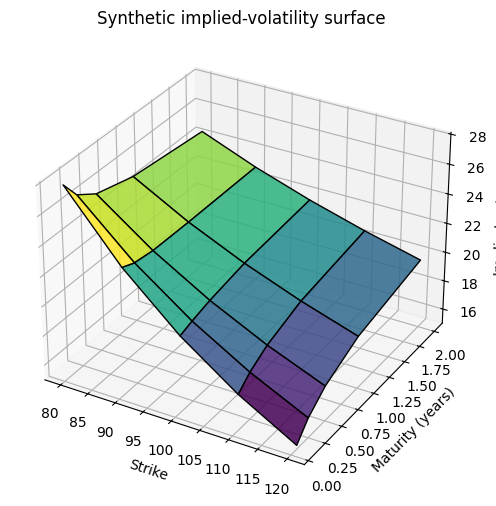

In [4]:
KK, TT = np.meshgrid(strikes, maturities)
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(KK, TT, iv_surface.values * 100, cmap="viridis", edgecolor="k", alpha=0.85)
ax.set_xlabel("Strike"); ax.set_ylabel("Maturity (years)"); ax.set_zlabel("Implied vol (%)")
ax.set_title("Synthetic implied-volatility surface")
plt.show()

## 3. Heston model and characteristic-function pricing

$$dS_t = rS_t\,dt + \sqrt{v_t}S_t\,dW_t^S, \qquad dv_t = \kappa(\theta - v_t)dt + \xi\sqrt{v_t}\,dW_t^v, \qquad dW^S dW^v = \rho\,dt$$

European call price:

$$C = S_0 P_1 - Ke^{-rT}P_2, \qquad P_j = \frac12 + \frac1\pi\int_0^\infty \mathrm{Re}\!\left[\frac{e^{-iu\ln K}\,\varphi_j(u)}{iu}\right]du$$

We use the "little Heston trap" formulation (Albrecher et al., 2007), which is numerically stable for long maturities.

In [5]:
U = np.linspace(1e-6, 200, 4000)   # integration grid (trapezoidal rule)

def heston_cf(u, T, v0, kappa, theta, xi, rho, j):
    # Characteristic function of ln(S_T) for P1 (j=1) and P2 (j=2)
    uj = 0.5 if j == 1 else -0.5
    bj = kappa - rho * xi if j == 1 else kappa
    a = kappa * theta
    x = np.log(S0)
    d = np.sqrt((rho * xi * 1j * u - bj)**2 - xi**2 * (2 * uj * 1j * u - u**2))
    g = (bj - rho * xi * 1j * u - d) / (bj - rho * xi * 1j * u + d)
    exp_dT = np.exp(-d * T)
    C_ = r * 1j * u * T + a / xi**2 * ((bj - rho * xi * 1j * u - d) * T
                                       - 2 * np.log((1 - g * exp_dT) / (1 - g)))
    D_ = (bj - rho * xi * 1j * u - d) / xi**2 * (1 - exp_dT) / (1 - g * exp_dT)
    return np.exp(C_ + D_ * v0 + 1j * u * x)


def heston_call(K, T, params):
    v0, kappa, theta, xi, rho = params
    P = []
    for j in (1, 2):
        integrand = np.real(np.exp(-1j * U * np.log(K)) *
                            heston_cf(U, T, v0, kappa, theta, xi, rho, j) / (1j * U))
        P.append(0.5 + np.trapezoid(integrand, U) / np.pi)
    return S0 * P[0] - K * np.exp(-r * T) * P[1]


# Check: with xi -> 0 and v0 = theta, Heston collapses to Black-Scholes
test = heston_call(100, 1.0, [0.04, 2.0, 0.04, 1e-4, 0.0])
print(f"Heston (xi~0): {test:.4f} | Black-Scholes (vol 20%): {bs_price(S0, 100, 1.0, r, 0.20):.4f}")

Heston (xi~0): 9.4134 | Black-Scholes (vol 20%): 9.4134


## 4. Heston calibration

$$\min_{\Theta}\ \frac1N\sum_i\left(P_i^{\text{Heston}} - P_i^{\text{Market}}\right)^2, \qquad \Theta = (v_0, \kappa, \theta, \xi, \rho)$$

In [6]:
grid = [(K, T) for T in maturities for K in strikes]
mkt = np.array([bs_price(S0, K, T, r, synthetic_iv(K, T)) for K, T in grid])

def residuals(params):
    return np.array([heston_call(K, T, params) for K, T in grid]) - mkt

x0 = [0.04, 1.5, 0.05, 0.5, -0.5]
bounds = ([1e-4, 0.1, 1e-4, 0.05, -0.99], [1.0, 10.0, 1.0, 2.0, 0.99])
res = least_squares(residuals, x0, bounds=bounds)

v0, kappa, theta, xi, rho = res.x
rmse = np.sqrt(np.mean(res.fun**2))
calib = pd.Series({"v0": v0, "kappa": kappa, "theta": theta, "xi": xi, "rho": rho})
print("Calibrated Heston parameters:"); print(calib.round(4))
print(f"\nFeller condition 2*kappa*theta > xi^2: {2*kappa*theta:.4f} > {xi**2:.4f} -> {2*kappa*theta > xi**2}")
print(f"Calibration RMSE: {rmse:.4f} (option-price units)")

Calibrated Heston parameters:
v0       0.0427
kappa    1.2399
theta    0.0570
xi       0.3601
rho     -0.6192
dtype: float64

Feller condition 2*kappa*theta > xi^2: 0.1412 > 0.1297 -> True
Calibration RMSE: 0.0332 (option-price units)


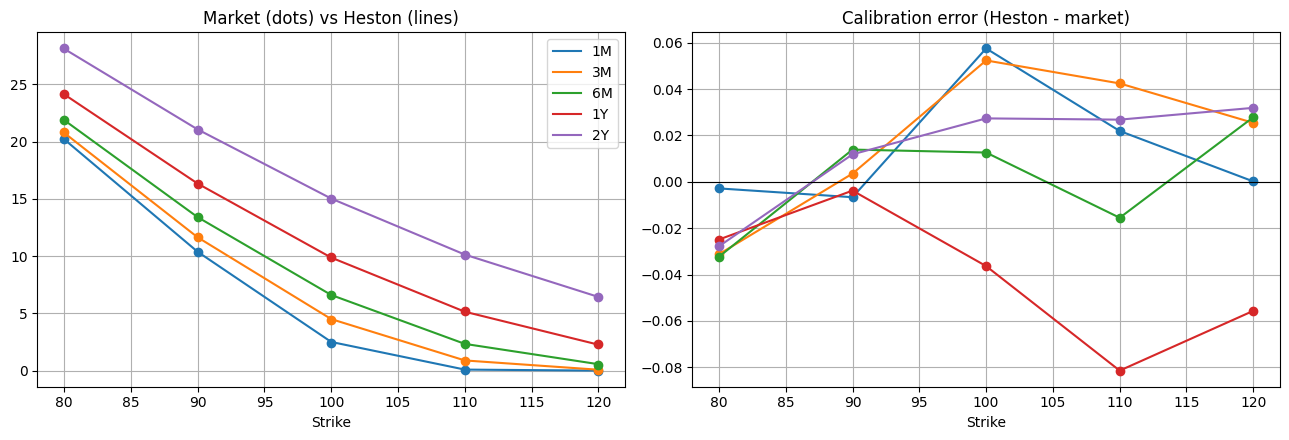

In [7]:
model = np.array([heston_call(K, T, res.x) for K, T in grid])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, (T, lab) in enumerate(zip(maturities, mat_labels)):
    sl = slice(i * len(strikes), (i + 1) * len(strikes))
    axes[0].plot(strikes, mkt[sl], "o", color=f"C{i}")
    axes[0].plot(strikes, model[sl], "-", color=f"C{i}", label=lab)
    axes[1].plot(strikes, model[sl] - mkt[sl], "o-", color=f"C{i}", label=lab)
axes[0].set_title("Market (dots) vs Heston (lines)"); axes[0].set_xlabel("Strike"); axes[0].legend()
axes[1].set_title("Calibration error (Heston - market)"); axes[1].set_xlabel("Strike"); axes[1].axhline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()

## 5. Monte Carlo engines

- **GBM** at constant volatility equal to the 1Y ATM implied vol.
- **Heston** with **full-truncation Euler**: $v^+ = \max(v, 0)$ is used in drift and diffusion so negative variance never enters the simulation.

In [8]:
N_PATHS, STEPS_PER_YEAR = 50_000, 252
sigma_gbm = synthetic_iv(S0, 1.0)

def simulate_gbm(T, n_paths=N_PATHS, sigma=sigma_gbm, seed=1):
    rng = np.random.default_rng(seed)
    n = int(T * STEPS_PER_YEAR); dt = T / n
    Z = rng.standard_normal((n_paths, n))
    log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    return S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), np.cumsum(log_inc, axis=1)]))


def simulate_heston(T, params=res.x, n_paths=N_PATHS, seed=1):
    v0, kappa, theta, xi, rho = params
    rng = np.random.default_rng(seed)
    n = int(T * STEPS_PER_YEAR); dt = T / n
    S = np.empty((n_paths, n + 1)); S[:, 0] = S0
    v = np.full(n_paths, v0)
    for t in range(n):
        z1 = rng.standard_normal(n_paths)
        z2 = rho * z1 + np.sqrt(1 - rho**2) * rng.standard_normal(n_paths)
        vp = np.maximum(v, 0.0)                                  # full truncation
        S[:, t + 1] = S[:, t] * np.exp((r - 0.5 * vp) * dt + np.sqrt(vp * dt) * z1)
        v = v + kappa * (theta - vp) * dt + xi * np.sqrt(vp * dt) * z2
    return S


gbm_1y, hes_1y = simulate_gbm(1.0), simulate_heston(1.0)

# Check: MC European ATM call vs closed forms
disc = np.exp(-r)
for name, paths, ref in [("GBM", gbm_1y, bs_price(S0, 100, 1, r, sigma_gbm)),
                         ("Heston", hes_1y, heston_call(100, 1.0, res.x))]:
    pay = disc * np.maximum(paths[:, -1] - 100, 0)
    print(f"{name:6s} MC: {pay.mean():.4f} ± {1.96*pay.std()/np.sqrt(len(pay)):.4f} | closed form: {ref:.4f}")

GBM    MC: 9.9551 ± 0.1321 | closed form: 9.9024
Heston MC: 9.9216 ± 0.1107 | closed form: 9.8661


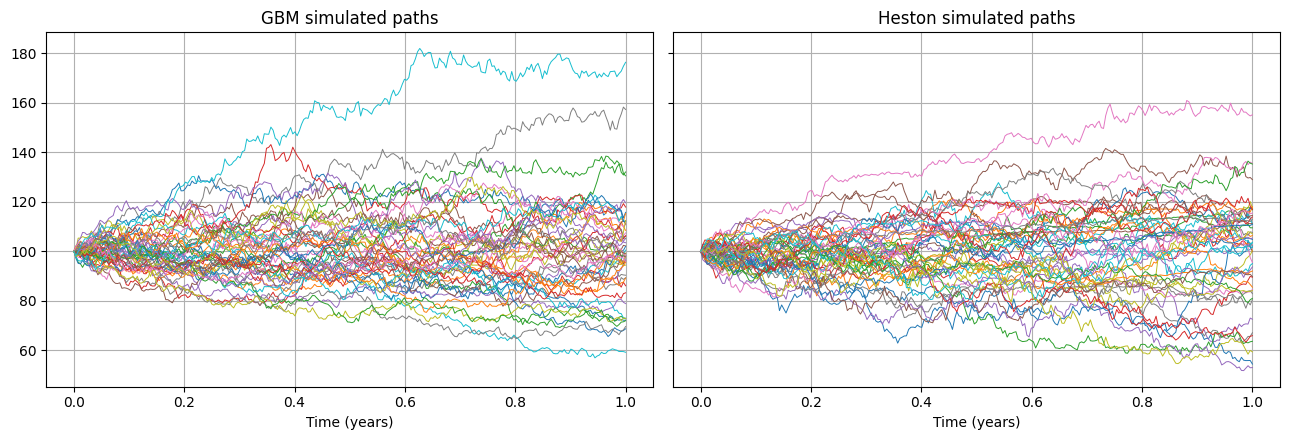

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
t = np.linspace(0, 1, gbm_1y.shape[1])
axes[0].plot(t, gbm_1y[:50].T, lw=0.7); axes[0].set_title("GBM simulated paths")
axes[1].plot(t, hes_1y[:50].T, lw=0.7); axes[1].set_title("Heston simulated paths")
for a in axes: a.set_xlabel("Time (years)")
plt.tight_layout(); plt.show()

## 6. Exotic options

In [10]:
def mc_summary(discounted_payoffs):
    m = discounted_payoffs.mean()
    se = discounted_payoffs.std(ddof=1) / np.sqrt(len(discounted_payoffs))
    return m, se, (m - 1.96 * se, m + 1.96 * se)

K = 100
asian_pay = {"GBM": disc * np.maximum(gbm_1y[:, 1:].mean(axis=1) - K, 0),
             "Heston": disc * np.maximum(hes_1y[:, 1:].mean(axis=1) - K, 0)}

H = 130
monitor = np.arange(0, 253, 21)               # monthly monitoring (discrete barrier)
def up_and_out(paths):
    alive = paths[:, monitor].max(axis=1) < H
    return disc * np.where(alive, np.maximum(paths[:, -1] - K, 0), 0), alive

rows = []
for model_name, paths in [("GBM", gbm_1y), ("Heston", hes_1y)]:
    m, se, ci = mc_summary(asian_pay[model_name])
    rows.append(["Asian call", model_name, m, se, ci[0], ci[1], np.nan])
    pay, alive = up_and_out(paths)
    m, se, ci = mc_summary(pay)
    rows.append([f"Up-and-out call (H={H})", model_name, m, se, ci[0], ci[1], 1 - alive.mean()])

exotics = pd.DataFrame(rows, columns=["Product", "Model", "Price", "Std error", "CI 95% low", "CI 95% high", "Knock-out prob"])
display(exotics.round(4))

,Product,Model,Price,Std error,CI 95% low,CI 95% high,Knock-out prob
0,Asian call,GBM,5.6293,0.0370,5.5567,5.7019,NaN
1,Up-and-out call (H=130),GBM,3.8413,0.0307,3.7810,3.9015,0.1742
2,Asian call,Heston,5.5387,0.0314,5.4772,5.6003,NaN
3,Up-and-out call (H=130),Heston,5.7501,0.0363,5.6789,5.8213,0.1235


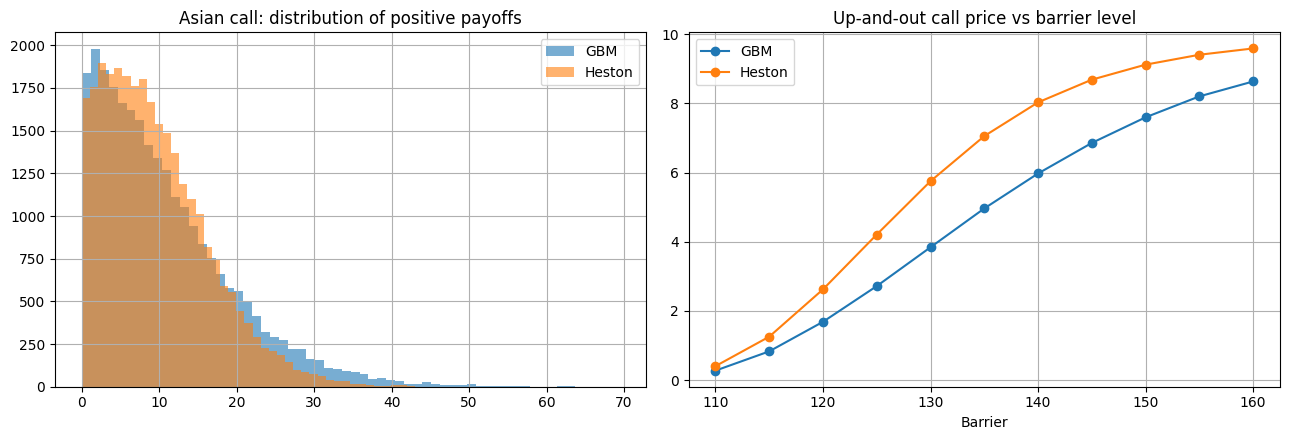

In [11]:
barriers = np.arange(110, 161, 5)
bar_px = pd.DataFrame({
    "GBM": [disc * np.where(gbm_1y[:, monitor].max(axis=1) < h, np.maximum(gbm_1y[:, -1] - K, 0), 0).mean() for h in barriers],
    "Heston": [disc * np.where(hes_1y[:, monitor].max(axis=1) < h, np.maximum(hes_1y[:, -1] - K, 0), 0).mean() for h in barriers],
}, index=barriers)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(asian_pay["GBM"][asian_pay["GBM"] > 0], bins=60, alpha=0.6, label="GBM")
axes[0].hist(asian_pay["Heston"][asian_pay["Heston"] > 0], bins=60, alpha=0.6, label="Heston")
axes[0].set_title("Asian call: distribution of positive payoffs"); axes[0].legend()
bar_px.plot(ax=axes[1], marker="o"); axes[1].set_title("Up-and-out call price vs barrier level"); axes[1].set_xlabel("Barrier")
plt.tight_layout(); plt.show()

## 7. Autocall: GBM vs Heston

| Parameter | Value |
|---|---:|
| Notional | €1,000 |
| Maturity | 1 year, quarterly observations |
| Autocall barrier | 100% of $S_0$ |
| Coupon | 8% p.a. (2% per quarter, accrued) |
| Capital protection barrier | 60% of $S_0$ (observed at maturity) |

In [12]:
NOTIONAL, COUPON, AC_BARRIER, PROT_BARRIER = 1000.0, 0.08, 1.00, 0.60
obs_idx = np.array([63, 126, 189, 252])       # quarterly observation dates
obs_t = obs_idx / 252

def price_autocall(paths):
    n = paths.shape[0]
    cashflow = np.zeros(n); pay_time = np.ones(n); redeemed_at = np.full(n, -1)
    alive = np.ones(n, dtype=bool)
    for q, (idx, tq) in enumerate(zip(obs_idx, obs_t)):
        call = alive & (paths[:, idx] >= AC_BARRIER * S0)
        cashflow[call] = NOTIONAL * (1 + COUPON * tq)
        pay_time[call] = tq; redeemed_at[call] = q
        alive &= ~call
    ST = paths[alive, -1] / S0
    cashflow[alive] = np.where(ST >= PROT_BARRIER, NOTIONAL, NOTIONAL * ST)
    pv = cashflow * np.exp(-r * pay_time)
    return {
        "pv": pv, "cashflow": cashflow, "redeemed_at": redeemed_at,
        "early_prob": (redeemed_at >= 0).mean(),
        "prob_by_date": [(redeemed_at == q).mean() for q in range(4)],
        "expected_life": pay_time.mean(),
        "loss_prob": (cashflow < NOTIONAL).mean(),
    }

ac = {"GBM": price_autocall(gbm_1y), "Heston": price_autocall(hes_1y)}
summary = pd.DataFrame({
    m: {"Value (€)": d["pv"].mean(),
        "Std error (€)": d["pv"].std(ddof=1) / np.sqrt(N_PATHS),
        "P(autocall)": d["early_prob"],
        "Expected life (years)": d["expected_life"],
        "P(capital loss)": d["loss_prob"]}
    for m, d in ac.items()})
display(summary.round(4))

diff = ac["Heston"]["pv"].mean() - ac["GBM"]["pv"].mean()
print(f"Heston - GBM: €{diff:.2f} ({diff / NOTIONAL:.2%} of notional)")

,GBM,Heston
Value (€),1003.1316,995.2266
Std error (€),0.1958,0.3785
P(autocall),0.7401,0.7802
Expected life (years),0.5379,0.5028
P(capital loss),0.0066,0.0255


Heston - GBM: €-7.91 (-0.79% of notional)


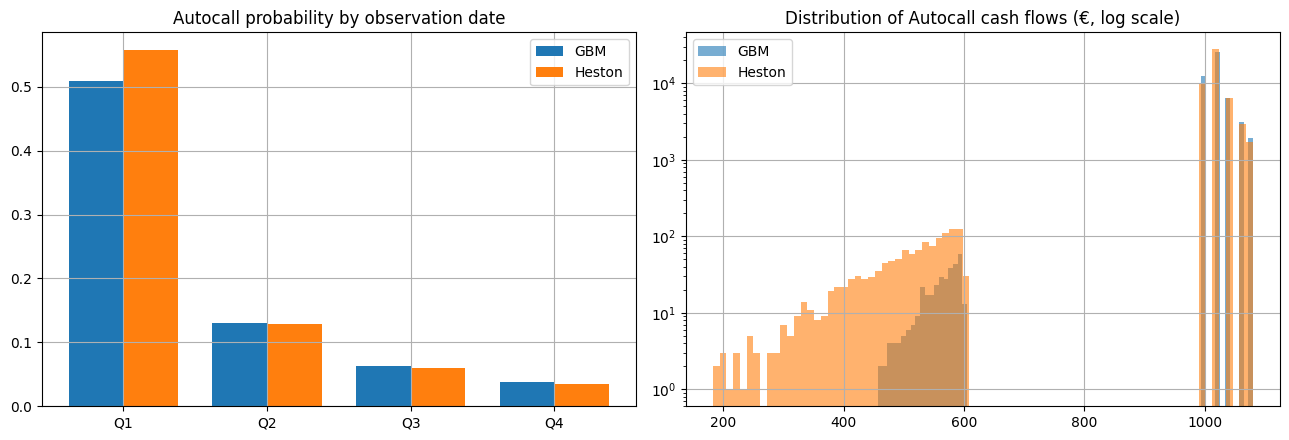

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(4); w = 0.38
axes[0].bar(x - w/2, ac["GBM"]["prob_by_date"], w, label="GBM")
axes[0].bar(x + w/2, ac["Heston"]["prob_by_date"], w, label="Heston")
axes[0].set_xticks(x, ["Q1", "Q2", "Q3", "Q4"]); axes[0].set_title("Autocall probability by observation date"); axes[0].legend()
for m in ["GBM", "Heston"]:
    axes[1].hist(ac[m]["cashflow"], bins=80, alpha=0.6, label=m)
axes[1].set_yscale("log"); axes[1].set_title("Distribution of Autocall cash flows (€, log scale)"); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Interpretation

- Heston is calibrated to a **negatively skewed** surface, so $\rho < 0$: when the underlying falls, volatility rises. This fattens the left tail of the return distribution relative to GBM.
- The Autocall investor is **short the downside** below the 60% barrier. A fatter left tail increases the probability of capital loss and lowers the product value.
- The early-redemption probabilities also differ between models, which changes the expected life and the coupon paid.
- **Conclusion:** for path-dependent, barrier-type products the volatility model is a first-order driver of value and risk, not a detail.

**Limitations:** synthetic surface; discrete barrier monitoring without Brownian-bridge correction; no variance reduction; risk-neutral probabilities are not real-world forecasts.